# **Student Performance Prediction**
**Dataset:** StudentPerformanceFactors.csv (lainguyn123, 6,607 siswa, 20 fitur)  

**Target:** Exam_Score (continuous regression)                         

**Referensi:** Ahmed et al. (2025) dan Santana-Perera et al. (2025)

## Install & Import Library

In [ ]:
# ═══════════════════════════════════════════════════════
#  Install & Import
# ═══════════════════════════════════════════════════════
!pip install xgboost lightgbm shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import ttest_rel  # paired t-test untuk 5-fold CV

# Warna konsisten
BLUE='#2E86AB'; ORANGE='#F6AE2D'; GREEN='#2DC653'; RED='#E84855'; PURPLE='#7B2D8B'
COLORS = [BLUE, ORANGE, GREEN, RED, PURPLE, '#1ABC9C']

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


## Load Data

In [ ]:
# ═══════════════════════════════════════════════════════
# Load Dataset
# ═══════════════════════════════════════════════════════
from google.colab import files; files.upload()

df = pd.read_csv('StudentPerformanceFactors.csv')
print(f'Shape     : {df.shape}')
df.head()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv
Shape     : (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Exploratory Data Analysis (EDA)

**Hasil Temuan:**
- Exam_Score: mean=67.24, std=3.89, range 55-101  
- Attendance & Hours_Studied punya korelasi kuat (r=0.58, r=0.44)  
- Missing value: Teacher_Quality(78), Parental_Ed(90), Distance(67)  
- Outlier: Exam_Score(104), Tutoring_Sessions(430)  


In [ ]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
# Cek missing values, duplikasi data, & statistik deskriptif
print(f'Missing :\n{df.isnull().sum()[df.isnull().sum()>0]}')
print(f'\nDuplikat: {df.duplicated().sum()}')
print(f'\nStatistik deskriptif:')
df.describe()

Missing :
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Duplikat: 0

Statistik deskriptif:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


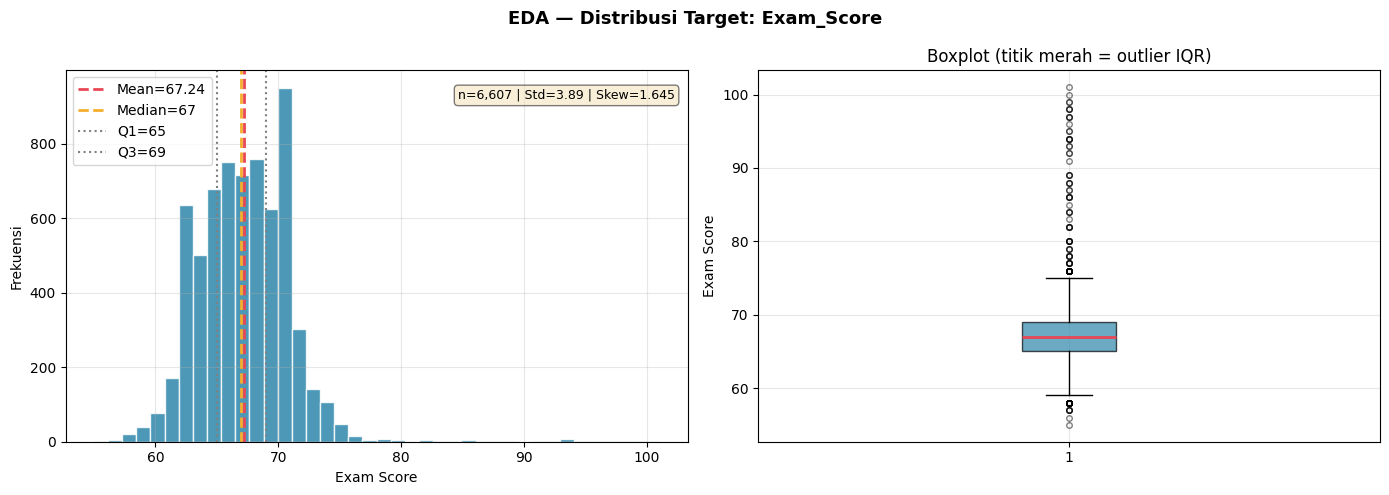

In [ ]:
# ═══════════════════════════════════════════════════════
# EDA: Distribusi Target (Exam_Score)
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA — Distribusi Target: Exam_Score', fontsize=13, fontweight='bold')

# Histogram
ax = axes[0]
ax.hist(df['Exam_Score'], bins=40, color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(df['Exam_Score'].mean(),            color=RED,    linestyle='--', lw=2, label=f"Mean={df['Exam_Score'].mean():.2f}")
ax.axvline(df['Exam_Score'].median(),          color=ORANGE, linestyle='--', lw=2, label=f"Median={df['Exam_Score'].median():.0f}")
ax.axvline(df['Exam_Score'].quantile(0.25),    color='gray', linestyle=':',  lw=1.5, label=f"Q1={df['Exam_Score'].quantile(0.25):.0f}")
ax.axvline(df['Exam_Score'].quantile(0.75),    color='gray', linestyle=':',  lw=1.5, label=f"Q3={df['Exam_Score'].quantile(0.75):.0f}")
ax.set_xlabel('Exam Score'); ax.set_ylabel('Frekuensi')
ax.legend(); ax.grid(alpha=0.3)
stats_text = f"n={len(df):,} | Std={df['Exam_Score'].std():.2f} | Skew={df['Exam_Score'].skew():.3f}"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Boxplot
ax2 = axes[1]
ax2.boxplot(df['Exam_Score'], patch_artist=True, vert=True,
            boxprops=dict(facecolor=BLUE, alpha=0.7),
            medianprops=dict(color=RED, lw=2),
            flierprops=dict(marker='o', color=RED, alpha=0.5, markersize=4))
ax2.set_ylabel('Exam Score'); ax2.grid(alpha=0.3)
ax2.set_title('Boxplot (titik merah = outlier IQR)')

plt.tight_layout()
plt.savefig('eda_01_target.png', dpi=150, bbox_inches='tight')
plt.show()

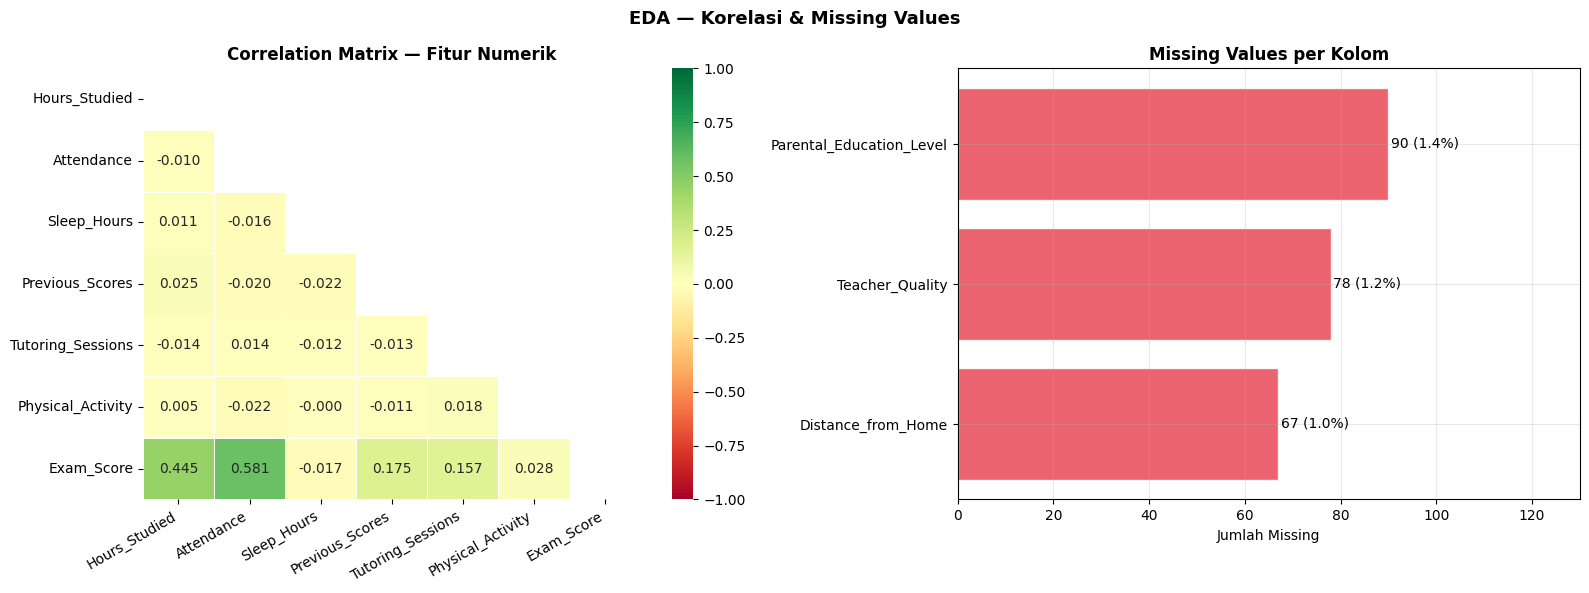


Korelasi dengan Exam_Score:
  Attendance               : r=0.5811  [KUAT]
  Hours_Studied            : r=0.4455  [KUAT]
  Previous_Scores          : r=0.1751  [SEDANG]
  Tutoring_Sessions        : r=0.1565  [SEDANG]
  Physical_Activity        : r=0.0278  [LEMAH]
  Sleep_Hours              : r=-0.0170  [LEMAH]


In [ ]:
# ═══════════════════════════════════════════════════════
#  EDA: Korelasi & Missing Values
# ═══════════════════════════════════════════════════════
num_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores',
            'Tutoring_Sessions','Physical_Activity','Exam_Score']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA — Korelasi & Missing Values', fontsize=13, fontweight='bold')

# Heatmap korelasi
corr_m = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_m, dtype=bool))
sns.heatmap(corr_m, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size':10})
axes[0].set_title('Correlation Matrix — Fitur Numerik', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Missing values
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values()
clr = [RED if v>50 else ORANGE for v in miss.values]
bars = axes[1].barh(miss.index, miss.values, color=clr, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, miss.values):
    axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                 f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)
axes[1].set_title('Missing Values per Kolom', fontweight='bold')
axes[1].set_xlabel('Jumlah Missing'); axes[1].set_xlim(0, 130)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_02_corr_missing.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKorelasi dengan Exam_Score:')
corr_exam = df[num_cols].corr()['Exam_Score'].drop('Exam_Score').sort_values(ascending=False)
for feat, val in corr_exam.items():
    s = 'KUAT' if abs(val)>0.3 else 'SEDANG' if abs(val)>0.1 else 'LEMAH'
    print(f'  {feat:<25}: r={val:.4f}  [{s}]')

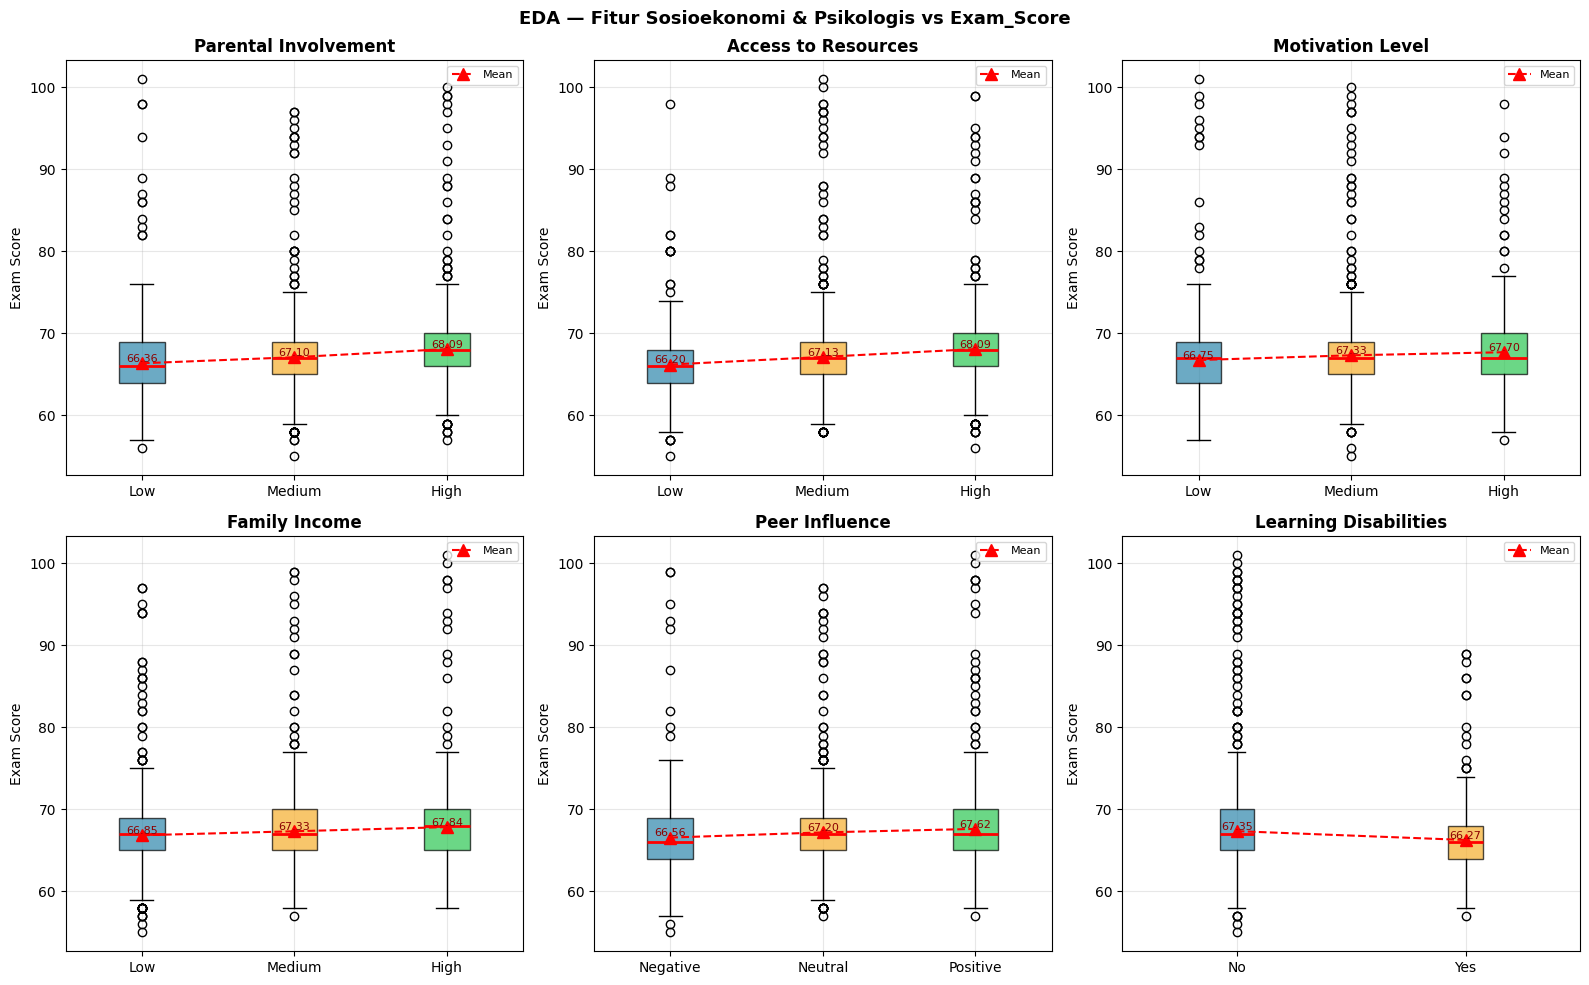

In [ ]:
# ═══════════════════════════════════════════════════════
# EDA: Fitur Sosioekonomi & Psikologis vs Exam_Score
# ═══════════════════════════════════════════════════════
socio_cols = ['Parental_Involvement','Access_to_Resources','Motivation_Level',
              'Family_Income','Peer_Influence','Learning_Disabilities']
order_map = {
    'Parental_Involvement'  : ['Low','Medium','High'],
    'Access_to_Resources'   : ['Low','Medium','High'],
    'Motivation_Level'      : ['Low','Medium','High'],
    'Family_Income'         : ['Low','Medium','High'],
    'Peer_Influence'        : ['Negative','Neutral','Positive'],
    'Learning_Disabilities' : ['No','Yes'],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Fitur Sosioekonomi & Psikologis vs Exam_Score', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(socio_cols):
    ax = axes[i]
    order = order_map[col]
    data_plot = [df[df[col]==cat]['Exam_Score'].dropna() for cat in order]
    bp = ax.boxplot(data_plot, labels=order, patch_artist=True,
                    medianprops=dict(color='red', lw=2))
    for patch, c in zip(bp['boxes'], COLORS):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    means = [d.mean() for d in data_plot]
    ax.plot(range(1, len(order)+1), means, 'r^--', markersize=8, label='Mean')
    # Annotate means
    for j, mean in enumerate(means):
        ax.text(j+1, mean+0.15, f'{mean:.2f}', ha='center', fontsize=8, color='darkred')
    ax.set_title(col.replace('_',' '), fontweight='bold')
    ax.set_ylabel('Exam Score'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_03_socioeconomic.png', dpi=150, bbox_inches='tight')
plt.show()

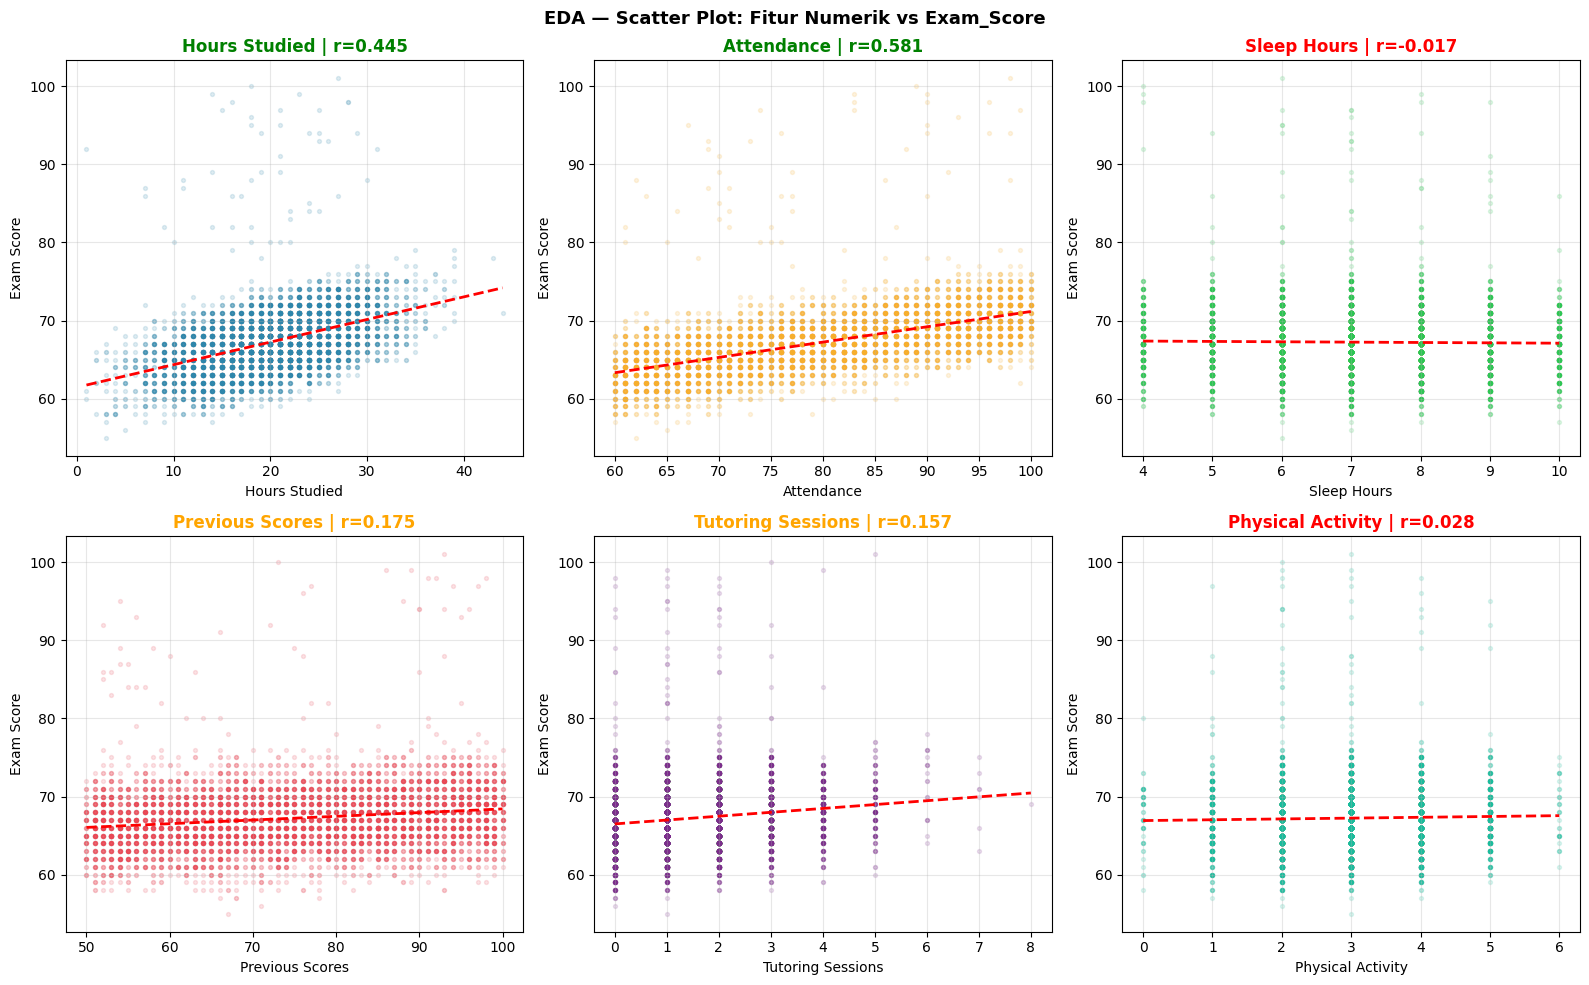

In [ ]:
# ═══════════════════════════════════════════════════════
# EDA: Scatter Numerik vs Exam_Score
# ═══════════════════════════════════════════════════════
num_feats = ['Hours_Studied','Attendance','Sleep_Hours',
             'Previous_Scores','Tutoring_Sessions','Physical_Activity']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Scatter Plot: Fitur Numerik vs Exam_Score', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_feats):
    ax = axes[i]
    corr_val = df[col].corr(df['Exam_Score'])
    ax.scatter(df[col], df['Exam_Score'], alpha=0.15, color=COLORS[i], s=8)
    z = np.polyfit(df[col], df['Exam_Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color='red', lw=2, linestyle='--')
    ax.set_xlabel(col.replace('_',' ')); ax.set_ylabel('Exam Score')
    title_color = 'green' if abs(corr_val)>0.3 else 'orange' if abs(corr_val)>0.1 else 'red'
    ax.set_title(f'{col.replace("_"," ")} | r={corr_val:.3f}',
                 fontweight='bold', color=title_color)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_04_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

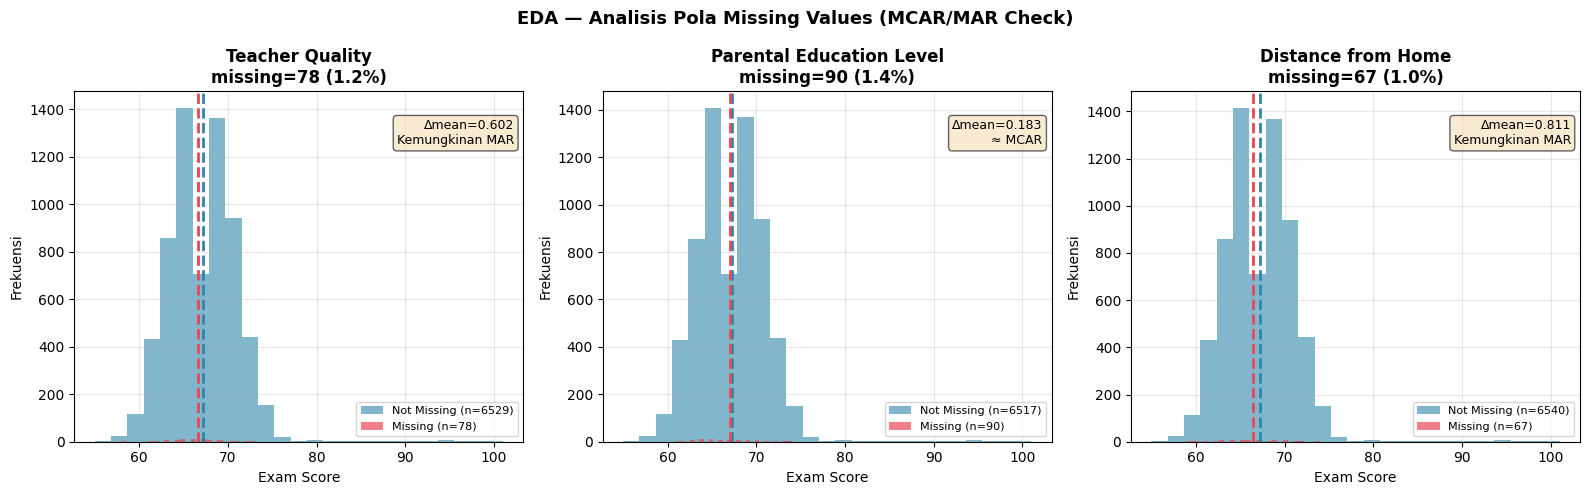

Interpretasi:
  MCAR (Missing Completely At Random) → imputasi mode aman
  MAR  (Missing At Random)            → imputasi mode masih valid, persentase <2%


In [ ]:
# ═══════════════════════════════════════════════════════
# EDA: Missing Value Pattern (MCAR/MAR Check)
# ═══════════════════════════════════════════════════════
miss_cols = ['Teacher_Quality','Parental_Education_Level','Distance_from_Home']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Analisis Pola Missing Values (MCAR/MAR Check)', fontsize=13, fontweight='bold')

for i, col in enumerate(miss_cols):
    ax = axes[i]
    m = df[col].isnull()
    ax.hist(df[~m]['Exam_Score'], bins=25, alpha=0.6, color=BLUE,
            label=f'Not Missing (n={(~m).sum()})')
    ax.hist(df[m]['Exam_Score'],  bins=25, alpha=0.7, color=RED,
            label=f'Missing (n={m.sum()})')
    ax.axvline(df[~m]['Exam_Score'].mean(), color=BLUE,   linestyle='--', lw=2)
    ax.axvline(df[m]['Exam_Score'].mean(),  color=RED,    linestyle='--', lw=2)
    diff = df[~m]['Exam_Score'].mean() - df[m]['Exam_Score'].mean()
    pola = '≈ MCAR' if abs(diff)<0.5 else 'Kemungkinan MAR'
    ax.set_title(f'{col.replace("_"," ")}\nmissing={m.sum()} ({m.sum()/len(df)*100:.1f}%)',
                 fontweight='bold')
    ax.text(0.98, 0.92, f'Δmean={diff:.3f}\n{pola}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    ax.set_xlabel('Exam Score'); ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_05_missing_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretasi:')
print('  MCAR (Missing Completely At Random) → imputasi mode aman')
print('  MAR  (Missing At Random)            → imputasi mode masih valid, persentase <2%')

### exam score

In [ ]:
# Deskripsi kolom exam score
df['Exam_Score'].describe().round(2)

,Exam_Score
count,6607.00
mean,67.24
std,3.89
min,55.00
25%,65.00
50%,67.00
75%,69.00
max,101.00


In [ ]:
# Distribusi nila exam score
df['Exam_Score'].value_counts().sort_index()

,count
Exam_Score,
55,1
56,1
57,4
58,22
59,40
60,77
61,171
62,264
63,371


In [ ]:
# Menghitung jumlah outliers
Q1 = df['Exam_Score'].quantile(0.25)
Q3 = df['Exam_Score'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Exam_Score'] < lower) | (df['Exam_Score'] > upper)]

len(outliers)

104

In [ ]:
# Distribusi nilai yang dianggap outliers
df.loc[(df['Exam_Score'] < lower) | (df['Exam_Score'] > upper), 'Exam_Score'].value_counts()

,count
Exam_Score,
58,22
76,16
80,5
77,5
86,4
94,4
82,4
78,4
57,4


### Tutoring Sessions

In [ ]:
# Deskripsi kolom tutoring sessions
df['Tutoring_Sessions'].value_counts().sort_index()

,count
Tutoring_Sessions,
0,1513
1,2179
2,1649
3,836
4,301
5,103
6,18
7,7
8,1


In [ ]:
# Deskripsi kolom tutoring sessions
df['Tutoring_Sessions'].describe().round(2)

,Tutoring_Sessions
count,6607.00
mean,1.49
std,1.23
min,0.00
25%,1.00
50%,1.00
75%,2.00
max,8.00


In [ ]:
# Menghitung jumlah outliers
Q1 = df['Tutoring_Sessions'].quantile(0.25)
Q3 = df['Tutoring_Sessions'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Tutoring_Sessions'] < lower) |
              (df['Tutoring_Sessions'] > upper)]

len(outliers)

430

In [ ]:
# Distribusi nilai yang dianggap outliers
outliers['Tutoring_Sessions'].value_counts()

,count
Tutoring_Sessions,
4,301
5,103
6,18
7,7
8,1


## Preprocessing


In [ ]:
# ═══════════════════════════════════════════════════════
# Preprocessing
# ═══════════════════════════════════════════════════════
df_clean = df.copy()

# ── 2A. Data Entry Error Correction ──────────────────
n_101 = (df_clean['Exam_Score'] == 101).sum()
df_clean['Exam_Score'] = df_clean['Exam_Score'].replace(101, 100)
print(f'[2A] Koreksi Exam_Score=101 → 100 : {n_101} baris')
print(f'     Justifikasi: domain knowledge — skor ujian max=100, bukan outlier statistik')

# ── 2B. Missing Value Imputation ─────────────────────
# Semua kolom missing → mode imputation
# Justifikasi: persentase kecil (<2%)
# Teacher_Quality & Distance_from_Home: MAR → mode valid
# Parental_Education_Level: ≈MCAR → mode valid
for col in ['Teacher_Quality','Parental_Education_Level','Distance_from_Home']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f'[2B] {col}: imputasi mode → "{mode_val}"')
print(f'     Total missing setelah imputasi: {df_clean.isnull().sum().sum()} ✅')

# ── 2C. Encoding ─────────────────────────────────────
# Ordinal Encoding untuk fitur yang punya urutan logis
ordinal_maps = {
    'Parental_Involvement'    : {'Low':0,'Medium':1,'High':2},
    'Access_to_Resources'     : {'Low':0,'Medium':1,'High':2},
    'Motivation_Level'        : {'Low':0,'Medium':1,'High':2},
    'Family_Income'           : {'Low':0,'Medium':1,'High':2},
    'Teacher_Quality'         : {'Low':0,'Medium':1,'High':2},
    'Parental_Education_Level': {'High School':0,'College':1,'Postgraduate':2},
    'Distance_from_Home'      : {'Near':0,'Moderate':1,'Far':2},
    'Peer_Influence'          : {'Negative':0,'Neutral':1,'Positive':2},
}
# Binary Encoding untuk fitur 2 nilai
binary_maps = {
    'Extracurricular_Activities': {'No':0,'Yes':1},
    'Internet_Access'           : {'No':0,'Yes':1},
    'School_Type'               : {'Public':0,'Private':1},
    'Learning_Disabilities'     : {'No':0,'Yes':1},
    'Gender'                    : {'Male':0,'Female':1},
}
for col, mapping in {**ordinal_maps, **binary_maps}.items():
    df_clean[col] = df_clean[col].map(mapping)
print(f'[2C] Encoding selesai — 8 ordinal, 5 binary')
print(f'     Justifikasi ordinal: fitur Low<Medium<High punya urutan natural')

print(f'\n✅ Preprocessing selesai! Shape: {df_clean.shape}')
df_clean.head()

[2A] Koreksi Exam_Score=101 → 100 : 1 baris
     Justifikasi: domain knowledge — skor ujian max=100, bukan outlier statistik
[2B] Teacher_Quality: imputasi mode → "Medium"
[2B] Parental_Education_Level: imputasi mode → "High School"
[2B] Distance_from_Home: imputasi mode → "Near"
     Total missing setelah imputasi: 0 ✅
[2C] Encoding selesai — 8 ordinal, 5 binary
     Justifikasi ordinal: fitur Low<Medium<High punya urutan natural

✅ Preprocessing selesai! Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0,2,0,7,73,0,1,0,0,1,0,2,3,0,0,0,0,67
1,19,64,0,1,0,8,59,0,1,2,1,1,0,0,4,0,1,1,1,61
2,24,98,1,1,1,7,91,1,1,2,1,1,0,1,4,0,2,0,0,74
3,29,89,0,1,1,8,98,1,1,1,1,1,0,0,4,0,0,1,0,71
4,19,92,1,1,1,6,65,1,1,3,1,2,0,1,4,0,1,0,1,70


## Feature Engineering

Novelty: 3 fitur baru berbasis domain knowledge  
Belum ada di Ahmed 2025 maupun Santana-Perera 2025  

In [ ]:
# ═══════════════════════════════════════════════════════
# Feature Engineering
# ═══════════════════════════════════════════════════════

# Fitur 1: Study_Efficiency
# Rasio jam belajar vs jam tidur
# Konsep: efisiensi belajar = output (jam belajar) / recovery (jam tidur)
df_clean['Study_Efficiency'] = df_clean['Hours_Studied'] / (df_clean['Sleep_Hours'] + 1e-5)

# Fitur 2: Parental_Support_Index
# Gabungan keterlibatan + pendidikan orang tua
# Konsep: dukungan orang tua bersifat multidimensi
df_clean['Parental_Support_Index'] = (
    df_clean['Parental_Involvement'] + df_clean['Parental_Education_Level']
) / 2

# Fitur 3: Socioeconomic_Index
# Gabungan pendapatan keluarga + akses ke sumber daya
# Konsep: indeks sosioekonomi siswa — menjawab future work dari paper Ahmed 2025
df_clean['Socioeconomic_Index'] = (
    df_clean['Family_Income'] + df_clean['Access_to_Resources']
) / 2

new_features = ['Study_Efficiency','Parental_Support_Index','Socioeconomic_Index']
print('Fitur baru yang dibuat:')
print(f'{"Fitur":<28} {"Min":>6} {"Max":>6} {"Mean":>8} {"Corr w/Exam_Score":>18}')
print('-'*70)
for feat in new_features:
    corr = df_clean[feat].corr(df_clean['Exam_Score'])
    print(f'  {feat:<26} {df_clean[feat].min():>6.2f} {df_clean[feat].max():>6.2f} '
          f'{df_clean[feat].mean():>8.3f} {corr:>18.4f}')

print(f'\nShape setelah feature engineering: {df_clean.shape}')
print(f'Total fitur input: {df_clean.shape[1]-1} (dari 19 → {df_clean.shape[1]-1})')

Fitur baru yang dibuat:
Fitur                           Min    Max     Mean  Corr w/Exam_Score
----------------------------------------------------------------------
  Study_Efficiency             0.12   9.50    2.980             0.3580
  Parental_Support_Index       0.00   2.00    0.891             0.1829
  Socioeconomic_Index          0.00   2.00    0.944             0.1856

Shape setelah feature engineering: (6607, 23)
Total fitur input: 22 (dari 19 → 22)


## Split + Scaling

Scaling — StandardScaler

> PENTING: fit HANYA pada train set  
> Mencegah data leakage informasi test ke train  


In [ ]:
# ═══════════════════════════════════════════════════════
# Train/Test Split + Scaling
# ═══════════════════════════════════════════════════════
X = df_clean.drop('Exam_Score', axis=1)
y = df_clean['Exam_Score']

# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler    = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns
)
X_test_sc  = pd.DataFrame(
    scaler.transform(X_test), columns=X.columns
)
X_full_sc  = pd.DataFrame(
    scaler.transform(X),  # ✅ transform saja, scaler sudah fit pada X_train
    columns=X.columns     # ✅ pertahankan nama kolom
)

print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

Train: (5285, 22) | Test: (1322, 22)


##

## Modeling: 7 Algoritma Regresi + GridSearch + 10-Fold CV

### GridSearchCV — Hyperparameter Tuning

> Hyperparameter tuning dengan 10-fold inner CV  
> Justified: dataset 6,607 baris → 10-fold lebih stabil  


In [ ]:
# ═══════════════════════════════════════════════════════
#  GridSearchCV untuk setiap model
# ═══════════════════════════════════════════════════════
# Hyperparameter grid
param_grids = {
    'Linear Regression': (
        LinearRegression(),
        {}  # Tidak ada hyperparameter
    ),
    'Ridge': (
        Ridge(),
        {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    ),
    'Lasso': (
        Lasso(),
        {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
    ),
    'Elastic Net': (
        ElasticNet(max_iter=10000),
        {'alpha'   : [0.0001, 0.001, 0.01, 0.1, 1.0],
         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {'n_estimators': [100, 200],
         'max_depth'   : [None, 10, 20],
         'min_samples_split': [2, 5]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=42, verbosity=0),
        {'n_estimators' : [100, 200],
         'learning_rate': [0.05, 0.1, 0.2],
         'max_depth'    : [3, 5, 7]}
    ),
    'LightGBM': (
        LGBMRegressor(random_state=42, verbose=-1),
        {'n_estimators' : [100, 200],
         'learning_rate': [0.05, 0.1, 0.2],
         'num_leaves'   : [31, 50, 70]}
    ),
}

best_models = {}
best_params_all = {}
print('GridSearchCV (10-fold, scoring=R²):')
print('-'*50)

for name, (model, params) in param_grids.items():
    if params:
        gs = GridSearchCV(model, params, cv=10, scoring='r2', n_jobs=-1)
        gs.fit(X_train_sc, y_train)
        best_models[name]     = gs.best_estimator_
        best_params_all[name] = gs.best_params_
        print(f'  {name:<20}: best_params = {gs.best_params_}')
    else:
        model.fit(X_train_sc, y_train)
        best_models[name]     = model
        best_params_all[name] = {}
        print(f'  {name:<20}: no hyperparameter tuning')

print('\n✅ GridSearch selesai!')

GridSearchCV (10-fold, scoring=R²):
--------------------------------------------------
  Linear Regression   : no hyperparameter tuning
  Ridge               : best_params = {'alpha': 10.0}
  Lasso               : best_params = {'alpha': 0.01}
  Elastic Net         : best_params = {'alpha': 0.01, 'l1_ratio': 0.9}
  Random Forest       : best_params = {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
  XGBoost             : best_params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  LightGBM            : best_params = {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31}

✅ GridSearch selesai!


## Evaluasi + 10-Fold CV + Paired t-test

In [ ]:
# ═══════════════════════════════════════════════════════
# Evaluasi Test Set
# ═══════════════════════════════════════════════════════
print('='*65)
print('Hasil Test Set (80/20 split)')
print('='*65)
print(f'{"Model":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-'*65)

results_test = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test_sc)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results_test[name] = {'RMSE':rmse,'MAE':mae,'R2':r2,'y_pred':y_pred}
    print(f'  {name:<20} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}')

best_test = max(results_test, key=lambda x: results_test[x]['R2'])
print(f'\n  🏆 Model terbaik: {best_test} (R²={results_test[best_test]["R2"]:.4f})')

Hasil Test Set (80/20 split)
Model                      RMSE      MAE       R²
-----------------------------------------------------------------
  Linear Regression      1.7994   0.4443   0.7709
  Ridge                  1.7998   0.4454   0.7708
  Lasso                  1.7990   0.4458   0.7710
  Elastic Net            1.7992   0.4459   0.7710
  Random Forest          2.1322   1.0426   0.6784
  XGBoost                1.8912   0.6812   0.7470
  LightGBM               1.9444   0.7818   0.7325

  🏆 Model terbaik: Lasso (R²=0.7710)


Hasil Temuan:  
- Model Lasso memberikan performa terbaik dengan R² = 0.7710, sedikit lebih tinggi dibandingkan hasil Santana-Perera (2025) (LightGBM, R² = 0.729) dan mendekati dengan hasil Ahmed et al. (Voting Regressor, R² = 0.7716). Hal ini menunjukkan bahwa model linear sederhana dapat memberikan kinerja prediksi yang kompetitif pada dataset ini.

In [ ]:
# ═══════════════════════════════════════════════════════
# 10-Fold Cross Validation
from sklearn.base import clone
# ═══════════════════════════════════════════════════════
print('='*75)
print('10-Fold Cross Validation')
print('='*75)
print(f'{"Model":<22} {"RMSE mean±std":>18} {"MAE mean±std":>18} {"R² mean±std":>18}')
print('-'*75)

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}

for name, model in best_models.items():
    rmse_s, mae_s, r2_s = [], [], []
    for tr_idx, val_idx in kf.split(X_full_sc):
        Xtr, Xval = X_full_sc.iloc[tr_idx], X_full_sc.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx],          y.iloc[val_idx]
        m = clone(model)
        m.fit(Xtr, ytr); yp = m.predict(Xval)
        rmse_s.append(np.sqrt(mean_squared_error(yval, yp)))
        mae_s.append(mean_absolute_error(yval, yp))
        r2_s.append(r2_score(yval, yp))
    cv_results[name] = {
        'rmse':rmse_s,'mae':mae_s,'r2':r2_s,
        'rmse_mean':np.mean(rmse_s),'rmse_std':np.std(rmse_s),
        'mae_mean' :np.mean(mae_s), 'mae_std' :np.std(mae_s),
        'r2_mean'  :np.mean(r2_s),  'r2_std'  :np.std(r2_s),
    }
    print(f'  {name:<20}'
          f'  {np.mean(rmse_s):.4f}±{np.std(rmse_s):.4f}'
          f'  {np.mean(mae_s):.4f}±{np.std(mae_s):.4f}'
          f'  {np.mean(r2_s):.4f}±{np.std(r2_s):.4f}')

best_cv = max(cv_results, key=lambda x: cv_results[x]['r2_mean'])
print(f'\n  🏆 Terbaik CV: {best_cv} '
      f'(R²={cv_results[best_cv]["r2_mean"]:.4f}±{cv_results[best_cv]["r2_std"]:.4f})')

10-Fold Cross Validation
Model                       RMSE mean±std       MAE mean±std        R² mean±std
---------------------------------------------------------------------------
  Linear Regression     1.9583±0.5669  0.4808±0.0791  0.7389±0.1089
  Ridge                 1.9583±0.5670  0.4810±0.0790  0.7389±0.1089
  Lasso                 1.9573±0.5671  0.4828±0.0790  0.7392±0.1089
  Elastic Net           1.9574±0.5671  0.4828±0.0790  0.7392±0.1089
  Random Forest         2.2583±0.4740  1.0701±0.0724  0.6596±0.0965
  XGBoost               2.0493±0.5347  0.6943±0.0647  0.7166±0.1051
  LightGBM              2.0909±0.5053  0.7932±0.0589  0.7062±0.0997

  🏆 Terbaik CV: Lasso (R²=0.7392±0.1089)


In [ ]:
# ═══════════════════════════════════════════════════════
# CEK NORMALITAS — Shapiro-Wilk Test
# Menentukan: paired t-test atau Wilcoxon?
# ═══════════════════════════════════════════════════════
from scipy.stats import shapiro, wilcoxon

print("="*60)
print("Shapiro-Wilk Test — Normalitas selisih R² per fold")
print("(baseline: Lasso)")
print("="*60)

lasso_r2 = cv_results['Lasso']['r2']

for name in cv_results:
    if name == 'Lasso':
        continue
    other_r2 = cv_results[name]['r2']
    diff = [a - b for a, b in zip(lasso_r2, other_r2)]
    stat, p_shapiro = shapiro(diff)
    normal = "✅ Normal" if p_shapiro > 0.05 else "❌ Tidak normal"
    print(f"  vs {name:<20}: W={stat:.4f}, p={p_shapiro:.4f} → {normal}")

print()
print("="*60)
print("Keputusan uji statistik:")
print("="*60)

all_normal = True
for name in cv_results:
    if name == 'Lasso':
        continue
    diff = [a - b for a, b in zip(
        cv_results['Lasso']['r2'],
        cv_results[name]['r2']
    )]
    _, p_shapiro = shapiro(diff)
    if p_shapiro <= 0.05:
        all_normal = False
        break

if all_normal:
    print("→ Semua selisih normal → Paired t-test valid ✅")
else:
    print("→ Ada selisih tidak normal → Wilcoxon lebih tepat ✅")
    print()
    print("Wilcoxon Signed-Rank Test:")
    print("-"*60)
    for name in cv_results:
        if name == 'Lasso':
            continue
        diff = [a - b for a, b in zip(
            cv_results['Lasso']['r2'],
            cv_results[name]['r2']
        )]
        try:
            stat, p_wilcox = wilcoxon(diff)
            sig = "✅ Signifikan" if p_wilcox < 0.05 else "⚠️  Tidak signifikan"
            print(f"  vs {name:<20}: W={stat:.4f}, p={p_wilcox:.4f} → {sig}")
        except Exception as e:
            print(f"  vs {name:<20}: {e}")


Shapiro-Wilk Test — Normalitas selisih R² per fold
(baseline: Lasso)
  vs Linear Regression   : W=0.9283, p=0.4315 → ✅ Normal
  vs Ridge               : W=0.9350, p=0.4989 → ✅ Normal
  vs Elastic Net         : W=0.9562, p=0.7420 → ✅ Normal
  vs Random Forest       : W=0.9440, p=0.5980 → ✅ Normal
  vs XGBoost             : W=0.9469, p=0.6315 → ✅ Normal
  vs LightGBM            : W=0.9762, p=0.9420 → ✅ Normal

Keputusan uji statistik:
→ Semua selisih normal → Paired t-test valid ✅


## Paired t-test (Robustness)

STEP 5 — Robustness: Paired t-test
Baseline: Lasso
  vs Linear Regression     : t=1.9103, p=0.0884  ⚠️  Tidak signifikan
  vs Ridge                 : t=1.8991, p=0.0900  ⚠️  Tidak signifikan
  vs Elastic Net           : t=1.0294, p=0.3302  ⚠️  Tidak signifikan
  vs Random Forest         : t=12.1401, p=0.0000  ✅ Signifikan (p<0.05)
  vs XGBoost               : t=9.3479, p=0.0000  ✅ Signifikan (p<0.05)
  vs LightGBM              : t=8.2719, p=0.0000  ✅ Signifikan (p<0.05)


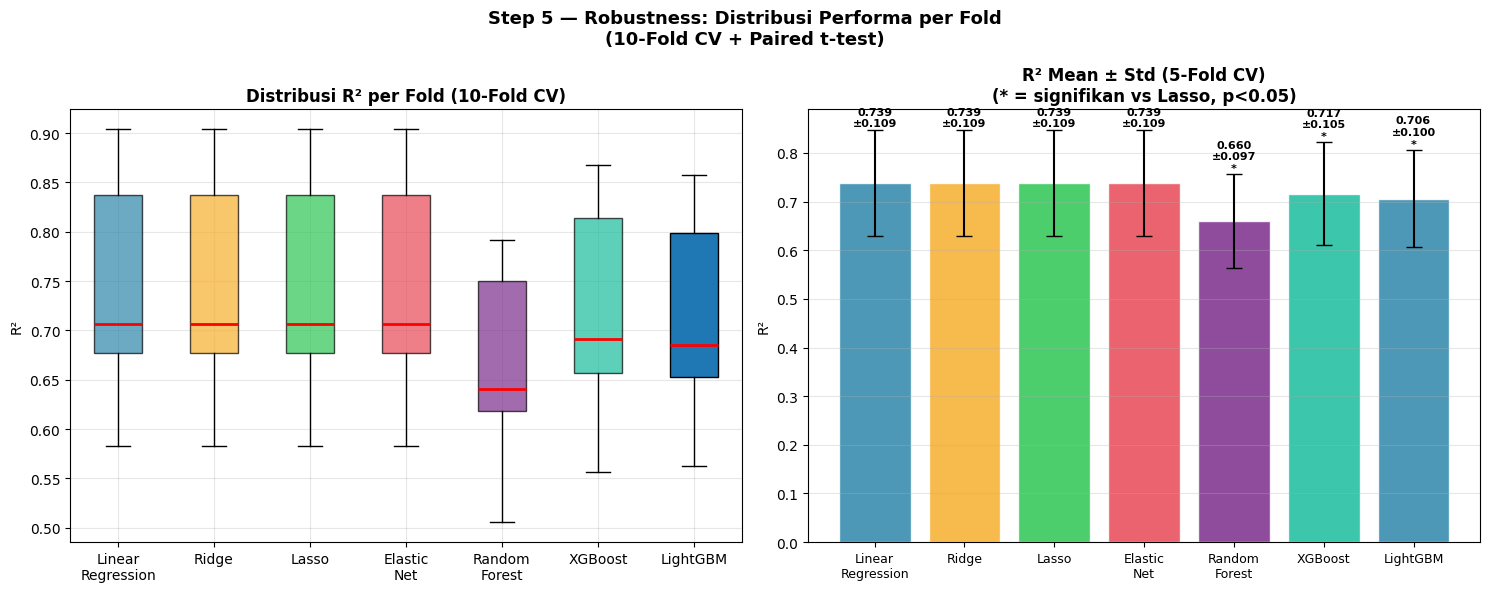


✅ Robustness check selesai!


In [ ]:
# ═══════════════════════════════════════════════════════
# Paired t-test + Visualisasi Robustness
# ═══════════════════════════════════════════════════════
# Paired t-test digunakan untuk membandingkan model pada hasil 10-fold CV.
from scipy.stats import ttest_rel

print('='*65)
print('STEP 5 — Robustness: Paired t-test')
print(f'Baseline: {best_cv}')
print('='*65)

ttest_results = {}
for name in cv_results:
    if name == best_cv: continue
    try:
        stat, p = ttest_rel(cv_results[best_cv]['r2'], cv_results[name]['r2'])
        sig = '✅ Signifikan (p<0.05)' if p<0.05 else '⚠️  Tidak signifikan'
        ttest_results[name] = {'stat': stat, 'p': p, 'sig': p<0.05}
        print(f'  vs {name:<22}: t={stat:.4f}, p={p:.4f}  {sig}')
    except Exception as e:
        print(f'  vs {name:<22}: {e}')

# ── Visualisasi 1: Boxplot R² per fold ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Step 5 — Robustness: Distribusi Performa per Fold\n(10-Fold CV + Paired t-test)',
             fontsize=13, fontweight='bold')

model_names = list(cv_results.keys())

# Boxplot R² per fold
ax1 = axes[0]
r2_folds = [cv_results[m]['r2'] for m in model_names]
bp = ax1.boxplot(r2_folds, labels=[m.replace(' ','\n') for m in model_names],
                 patch_artist=True, medianprops=dict(color='red', lw=2))
for patch, c in zip(bp['boxes'], COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax1.set_title('Distribusi R² per Fold (10-Fold CV)', fontweight='bold')
ax1.set_ylabel('R²'); ax1.grid(alpha=0.3)

# Bar R² mean ± std + anotasi signifikansi
ax2 = axes[1]
r2_means = [cv_results[m]['r2_mean'] for m in model_names]
r2_stds  = [cv_results[m]['r2_std']  for m in model_names]
bars = ax2.bar(range(len(model_names)), r2_means, yerr=r2_stds,
               color=COLORS, alpha=0.85, edgecolor='white',
               capsize=6, error_kw={'ecolor':'black','linewidth':1.5})
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels([m.replace(' ','\n') for m in model_names], fontsize=9)
ax2.set_title('R² Mean ± Std (5-Fold CV)\n(* = signifikan vs Lasso, p<0.05)', fontweight='bold')
ax2.set_ylabel('R²'); ax2.grid(alpha=0.3, axis='y')
for i, (mean, std) in enumerate(zip(r2_means, r2_stds)):
    name = model_names[i]
    label = f'{mean:.3f}\n±{std:.3f}'
    # Tambah tanda * jika signifikan
    if name in ttest_results and ttest_results[name]['sig']:
        label += '\n*'
    ax2.text(i, mean+std+0.003, label,
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('robustness_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Robustness check selesai!')

## Visualisasi Prediksi — Actual vs Predicted

> Scatter plot nilai ujian aktual vs prediksi model terbaik (Lasso).
> Semakin dekat titik ke garis diagonal = semakin akurat prediksi.
> Warna titik menunjukkan besarnya error (residual).


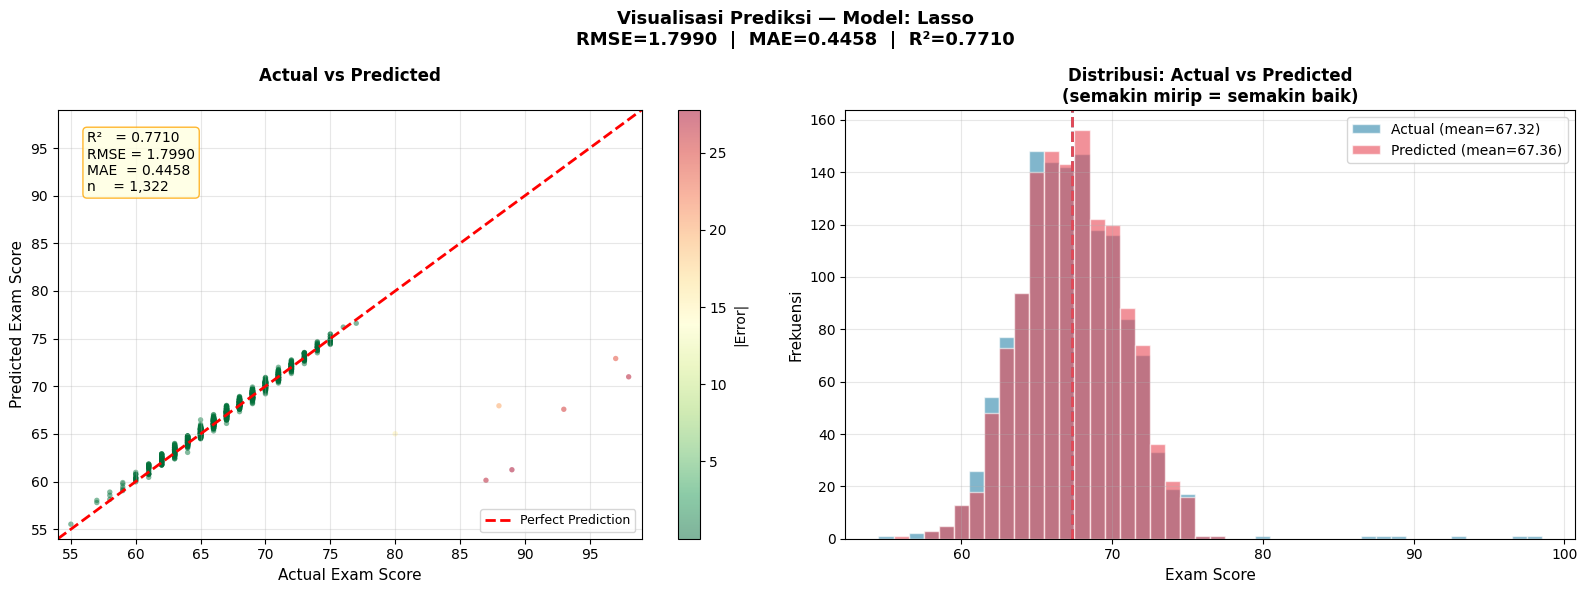


Statistik Prediksi:
  Actual   — mean=67.3177, std=3.7597
  Predicted — mean=67.3637, std=3.2894
  Selisih mean : 0.0460   (mendekati 0 = tidak bias)
  Selisih std  : 0.4703
  Max overestimasi  : -1.4732   (prediksi terlalu tinggi)
  Max underestimasi : 27.7611   (prediksi terlalu rendah)

Akurasi prediksi per toleransi error:
  Error ≤ 1 poin : 99.2% siswa
  Error ≤ 2 poin : 99.5% siswa
  Error ≤ 5 poin : 99.5% siswa

✅ Visualisasi prediksi selesai!


In [ ]:
# ═══════════════════════════════════════════════════════
#  Visualisasi Prediksi — Actual vs Predicted
# ═══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Prediksi menggunakan model terbaik (Lasso)
best_model  = best_models[best_cv]  # Lasso
y_pred      = best_model.predict(X_test_sc)
y_actual    = y_test.values

# Hitung error
residuals   = y_actual - y_pred
mae         = np.mean(np.abs(residuals))
rmse        = np.sqrt(np.mean(residuals**2))
r2          = 1 - np.sum(residuals**2) / np.sum((y_actual - y_actual.mean())**2)

fig = plt.figure(figsize=(16, 6))
fig.suptitle(
    f'Visualisasi Prediksi — Model: {best_cv}\n'
    f'RMSE={rmse:.4f}  |  MAE={mae:.4f}  |  R²={r2:.4f}',
    fontsize=13, fontweight='bold'
)

# ── Plot 1: Scatter Actual vs Predicted ──────────────────
ax1 = fig.add_subplot(1, 2, 1)

# Scatter plot — warna berdasarkan error
errors = np.abs(residuals)
sc = ax1.scatter(
    y_actual, y_pred,
    c=errors, cmap='RdYlGn_r',
    alpha=0.5, s=15, edgecolors='none'
)
plt.colorbar(sc, ax=ax1, label='|Error|')

# Garis diagonal sempurna (perfect prediction)
min_val = min(y_actual.min(), y_pred.min()) - 1
max_val = max(y_actual.max(), y_pred.max()) + 1
ax1.plot(
    [min_val, max_val], [min_val, max_val],
    'r--', lw=2, label='Perfect Prediction'
)

# Anotasi metrik
ax1.text(
    0.05, 0.95,
    f'R²   = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE  = {mae:.4f}\nn    = {len(y_actual):,}',
    transform=ax1.transAxes, va='top', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow',
              alpha=0.8, edgecolor='orange')
)

ax1.set_xlabel('Actual Exam Score', fontsize=11)
ax1.set_ylabel('Predicted Exam Score', fontsize=11)
ax1.set_title('Actual vs Predicted\n', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)

# ── Plot 2: Distribution Actual vs Predicted ─────────────
ax2 = fig.add_subplot(1, 2, 2)

bins = np.arange(
    min(y_actual.min(), y_pred.min()) - 0.5,
    max(y_actual.max(), y_pred.max()) + 1.5,
    1
)

ax2.hist(
    y_actual, bins=bins,
    alpha=0.6, color='#2E86AB',
    label=f'Actual (mean={y_actual.mean():.2f})',
    edgecolor='white'
)
ax2.hist(
    y_pred, bins=bins,
    alpha=0.6, color='#E84855',
    label=f'Predicted (mean={y_pred.mean():.2f})',
    edgecolor='white'
)

# Garis mean
ax2.axvline(
    y_actual.mean(), color='#2E86AB',
    linestyle='--', lw=2
)
ax2.axvline(
    y_pred.mean(), color='#E84855',
    linestyle='--', lw=2
)

ax2.set_xlabel('Exam Score', fontsize=11)
ax2.set_ylabel('Frekuensi', fontsize=11)
ax2.set_title('Distribusi: Actual vs Predicted\n'
              '(semakin mirip = semakin baik)', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistik tambahan ────────────────────────────────────
print('\nStatistik Prediksi:')
print(f'  Actual   — mean={y_actual.mean():.4f}, std={y_actual.std():.4f}')
print(f'  Predicted — mean={y_pred.mean():.4f}, std={y_pred.std():.4f}')
print(f'  Selisih mean : {abs(y_actual.mean()-y_pred.mean()):.4f}   (mendekati 0 = tidak bias)')
print(f'  Selisih std  : {abs(y_actual.std()-y_pred.std()):.4f}')
print(f'  Max overestimasi  : {residuals.min():.4f}   (prediksi terlalu tinggi)')
print(f'  Max underestimasi : {residuals.max():.4f}   (prediksi terlalu rendah)')
print()

# Error distribution
within_1 = np.mean(np.abs(residuals) <= 1) * 100
within_2 = np.mean(np.abs(residuals) <= 2) * 100
within_5 = np.mean(np.abs(residuals) <= 5) * 100
print('Akurasi prediksi per toleransi error:')
print(f'  Error ≤ 1 poin : {within_1:.1f}% siswa')
print(f'  Error ≤ 2 poin : {within_2:.1f}% siswa')
print(f'  Error ≤ 5 poin : {within_5:.1f}% siswa')
print('\n✅ Visualisasi prediksi selesai!')

## Interpretasi: SHAP + PDP

Novelty:  
- Referensi dari Ahmed (2025) tidak melakukan SHAP/PDP pada dataset ini sama sekali  
- PDP belum digunakan di kedua referensi  Ahmed (2025) & Santana-Perera (2025)
- Fokus pada fitur sosioekonomi & psikologis  
(menjawab future work dari referensi Ahmed 2025)  


Model untuk SHAP: Lasso


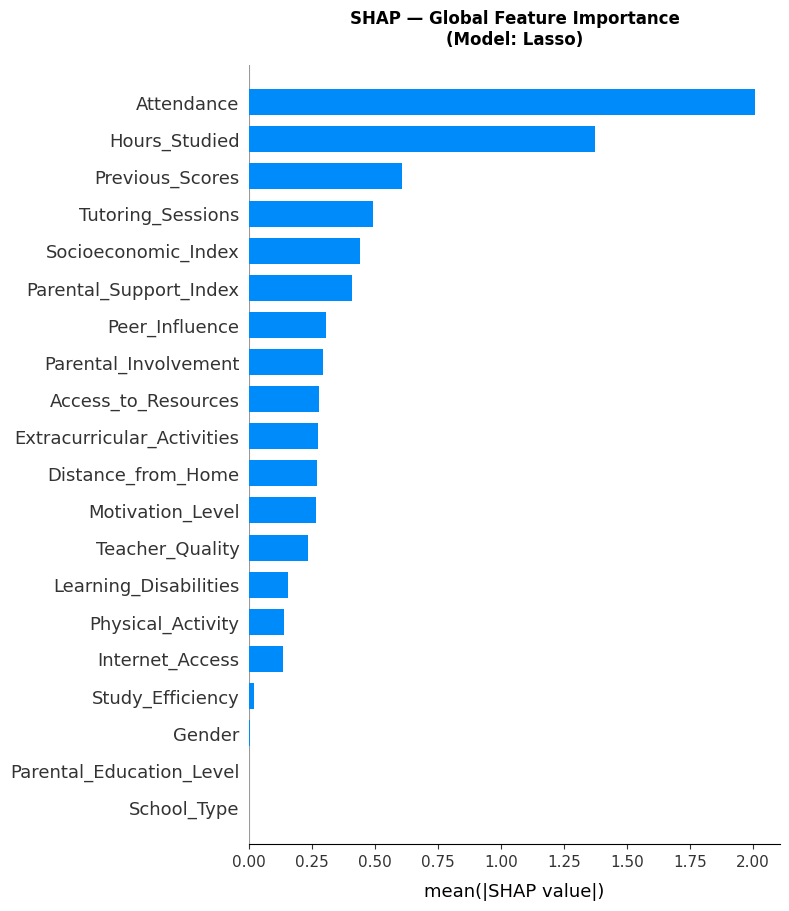

In [ ]:
# ═══════════════════════════════════════════════════════
# SHAP: Global Feature Importance
# ═══════════════════════════════════════════════════════
# Gunakan model terbaik dari CV
best_model = best_models[best_cv]
print(f'Model untuk SHAP: {best_cv}')

# Pilih explainer sesuai tipe model
if best_cv in ['XGBoost','LightGBM','Random Forest','Gradient Boosting']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train_sc)

shap_values = explainer.shap_values(X_test_sc)

n_features = X_test_sc.shape[1]
fig_height = max(8, n_features * 0.45)

plt.figure(figsize=(12, fig_height))  # ← lebar 10→12
shap.summary_plot(shap_values, X_test_sc, plot_type='bar', show=False)
plt.title(f'SHAP — Global Feature Importance\n(Model: {best_cv})',
          fontweight='bold', pad=15)
plt.xlabel('mean(|SHAP value|)', labelpad=10)  # ← ganti label lebih pendek
plt.tight_layout(rect=[0, 0.03, 1, 1])         # ← kasih ruang bawah
plt.savefig('shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Model untuk SHAP: Lasso


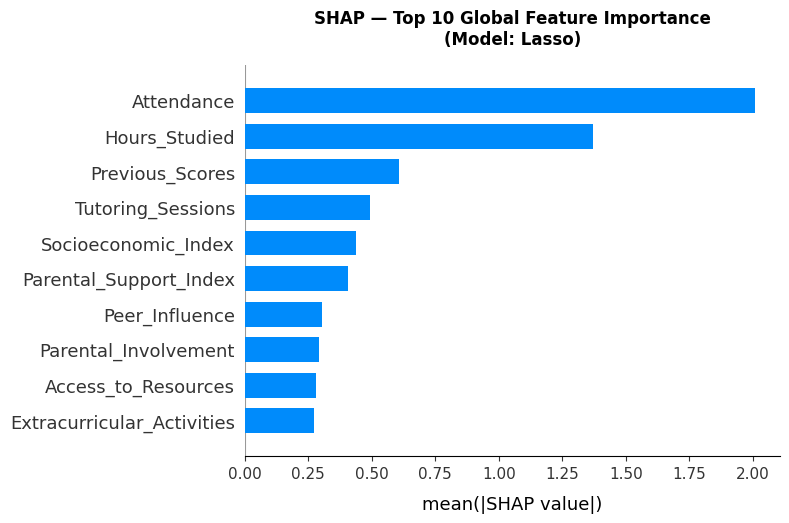

In [ ]:
# ═══════════════════════════════════════════════════════
# SHAP: Global Feature Importance (Top 10 Features)
# ═══════════════════════════════════════════════════════
best_model = best_models[best_cv]
print(f'Model untuk SHAP: {best_cv}')

# Pilih explainer sesuai tipe model
if best_cv in ['XGBoost','LightGBM','Random Forest','Gradient Boosting']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train_sc)

shap_values = explainer.shap_values(X_test_sc)

# Set jumlah fitur yang ditampilkan
max_features = 10

fig_height = max(6, max_features * 0.6)

plt.figure(figsize=(12, fig_height))
shap.summary_plot(
    shap_values,
    X_test_sc,
    plot_type='bar',
    max_display=max_features,  # ← ini kuncinya
    show=False
)

plt.title(f'SHAP — Top {max_features} Global Feature Importance\n(Model: {best_cv})',
          fontweight='bold', pad=15)
plt.xlabel('mean(|SHAP value|)', labelpad=10)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('shap_global_bar_top10.png', dpi=150, bbox_inches='tight')
plt.show()

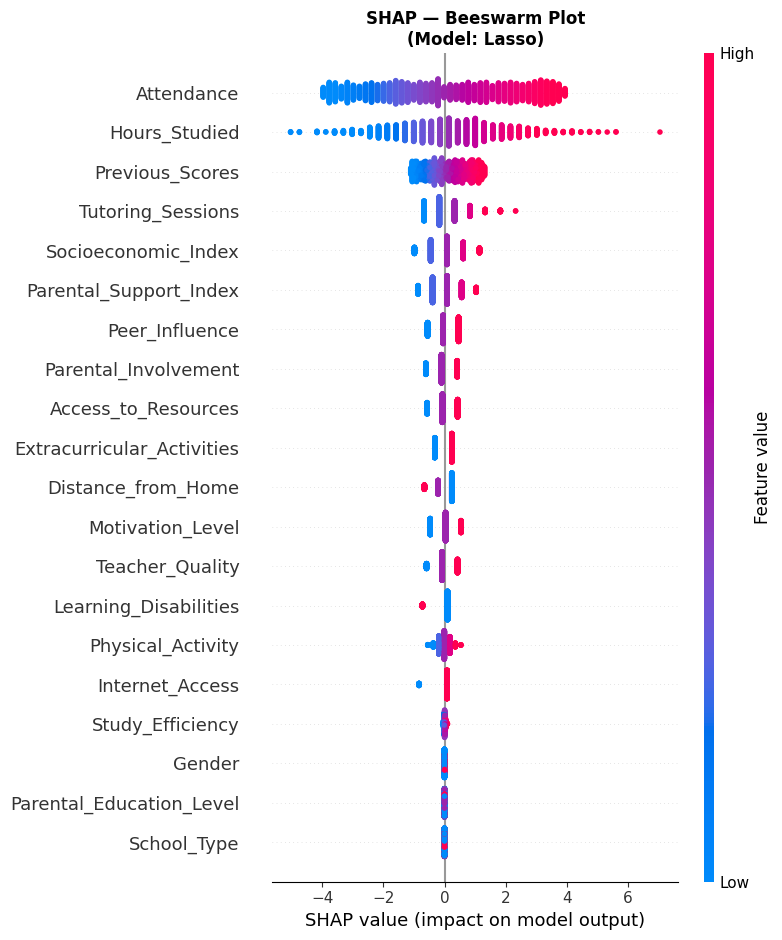


Ranking SHAP Global Importance:
                   Feature  SHAP_mean
                Attendance   2.006708
             Hours_Studied   1.372598
           Previous_Scores   0.608097
         Tutoring_Sessions   0.493080
       Socioeconomic_Index   0.438410
    Parental_Support_Index   0.406093
            Peer_Influence   0.302939
      Parental_Involvement   0.293563
       Access_to_Resources   0.278923
Extracurricular_Activities   0.272198
        Distance_from_Home   0.269090
          Motivation_Level   0.266663
           Teacher_Quality   0.233990
     Learning_Disabilities   0.152679
         Physical_Activity   0.136895
           Internet_Access   0.132127
          Study_Efficiency   0.018141
                    Gender   0.002235
               Sleep_Hours   0.000000
             Family_Income   0.000000
               School_Type   0.000000
  Parental_Education_Level   0.000000


In [ ]:
# ═══════════════════════════════════════════════════════
# SHAP: Beeswarm Plot (Arah & Magnitude)
# ═══════════════════════════════════════════════════════
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sc, show=False)
plt.title(f'SHAP — Beeswarm Plot\n(Model: {best_cv})', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranking fitur
shap_importance = pd.DataFrame({
    'Feature'   : X_test_sc.columns,
    'SHAP_mean' : np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_mean', ascending=False)

print('\nRanking SHAP Global Importance:')
print(shap_importance.to_string(index=False))

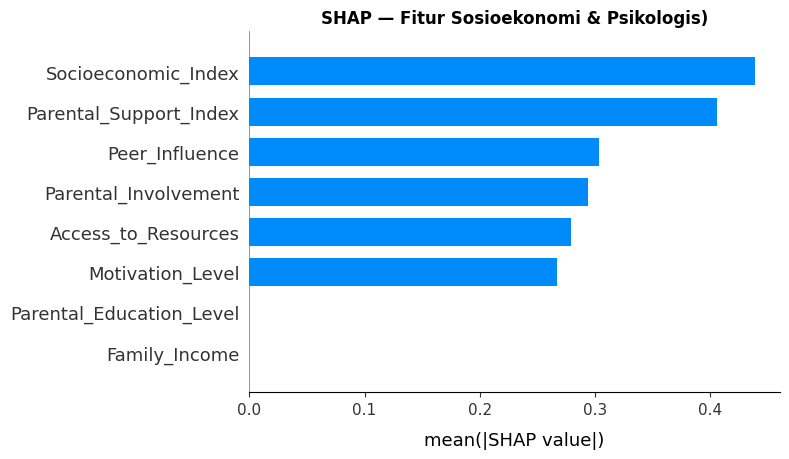

In [ ]:
# ═══════════════════════════════════════════════════════
# SHAP: Fokus Fitur Sosioekonomi & Psikologis
# ═══════════════════════════════════════════════════════
# menjawab future work Ahmed 2025
socio_psych_features = [
    'Family_Income', 'Access_to_Resources', 'Parental_Involvement',
    'Motivation_Level', 'Peer_Influence', 'Parental_Education_Level',
    'Socioeconomic_Index', 'Parental_Support_Index'
]

# Filter hanya fitur yang ada
socio_available = [f for f in socio_psych_features if f in X_test_sc.columns]
socio_idx = [list(X_test_sc.columns).index(f) for f in socio_available]

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, socio_idx],
    X_test_sc[socio_available],
    plot_type='bar', show=False
)
plt.title('SHAP — Fitur Sosioekonomi & Psikologis)',
          fontweight='bold')
plt.xlabel('mean(|SHAP value|)', labelpad=10)
plt.tight_layout()
plt.savefig('shap_socioeconomic.png', dpi=150, bbox_inches='tight')
plt.show()

Fitur PDP tersedia: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Socioeconomic_Index', 'Parental_Support_Index', 'Peer_Influence', 'Family_Income']
Jumlah: 8


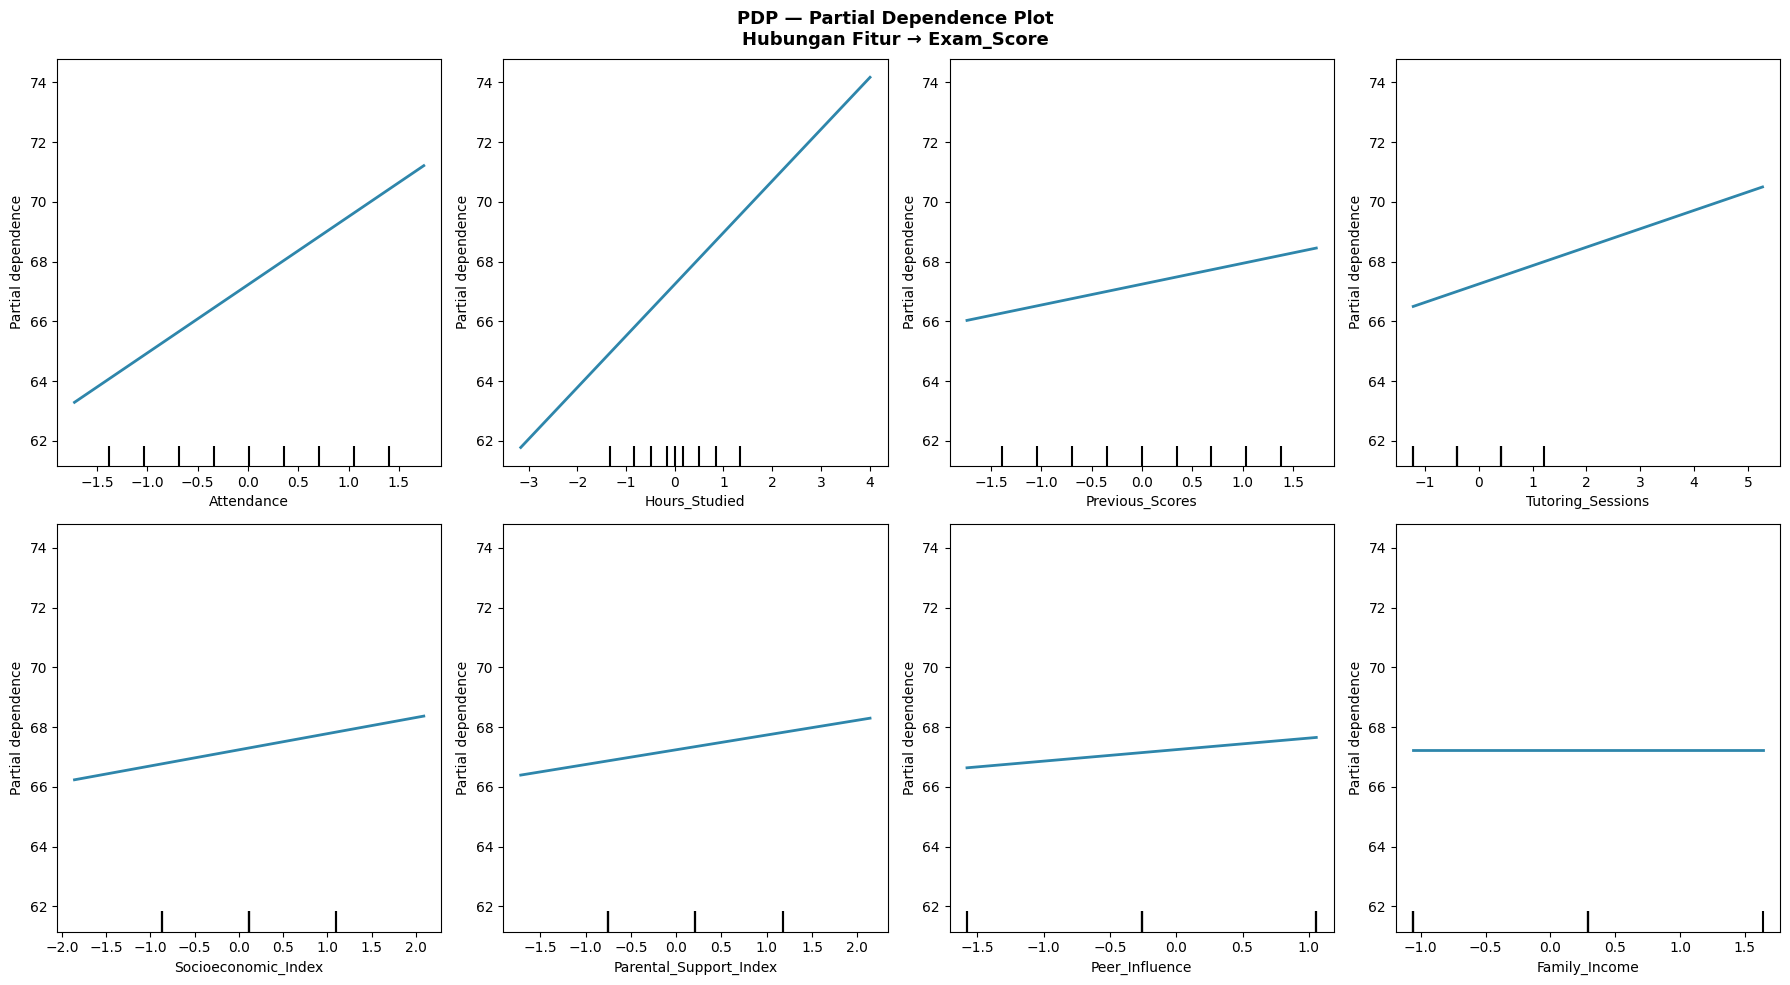

✅ PDP selesai!


In [ ]:
# ═══════════════════════════════════════════════════════
# PDP — Partial Dependence Plot
# ═══════════════════════════════════════════════════════
from sklearn.inspection import PartialDependenceDisplay

pdp_features = [
    'Attendance',             # rank 1 — dominan
    'Hours_Studied',          # rank 2 — dominan
    'Previous_Scores',        # rank 3 — akademik
    'Tutoring_Sessions',      # rank 4 — dukungan
    'Socioeconomic_Index',    # rank 5 — FE baru ★
    'Parental_Support_Index', # rank 6 — FE baru ★
    'Peer_Influence',         # rank 7 — psikologis
    'Family_Income',          # SHAP=0 — buktikan flat ★
]

# Pastikan kolom tersedia
pdp_avail = [f for f in pdp_features if f in X_full_sc.columns]
print(f"Fitur PDP tersedia: {pdp_avail}")
print(f"Jumlah: {len(pdp_avail)}")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('PDP — Partial Dependence Plot\n'
             'Hubungan Fitur → Exam_Score',
             fontsize=13, fontweight='bold')

PartialDependenceDisplay.from_estimator(
    best_model, X_full_sc, pdp_avail,
    ax=axes.flatten()[:len(pdp_avail)],
    line_kw={'color': '#2E86AB', 'linewidth': 2}
)

for ax in axes.flatten()[len(pdp_avail):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('pdp_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PDP selesai!")


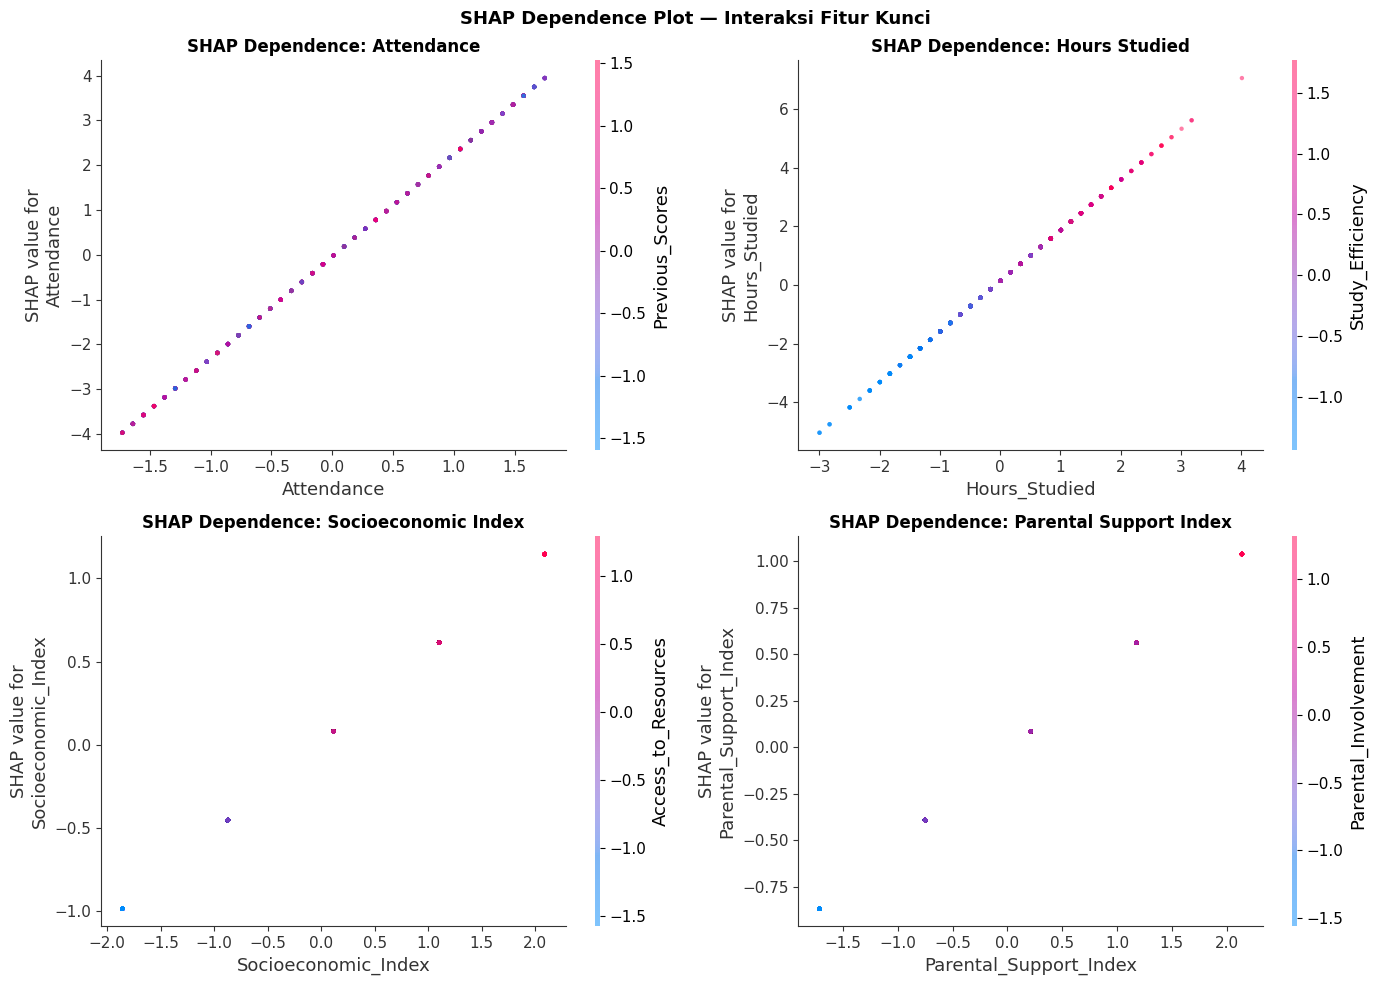

In [ ]:
# ═══════════════════════════════════════════════════════
# SHAP Dependence Plot: Interaksi Fitur
# ═══════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plot — Interaksi Fitur Kunci', fontsize=13, fontweight='bold')

dep_features = ['Attendance', 'Hours_Studied', 'Socioeconomic_Index', 'Parental_Support_Index']

for i, feat in enumerate(dep_features):
    if feat in X_test_sc.columns:
        ax = axes.flatten()[i]
        shap.dependence_plot(
            feat, shap_values, X_test_sc,
            ax=ax, show=False,
            dot_size=10, alpha=0.5
        )
        ax.set_title(f'SHAP Dependence: {feat.replace("_"," ")}', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()